In [36]:
!pip3 install seaborn

In [37]:
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Normalized Insertion, Deletion, and Substitution

<Axes: xlabel='model', ylabel='share'>

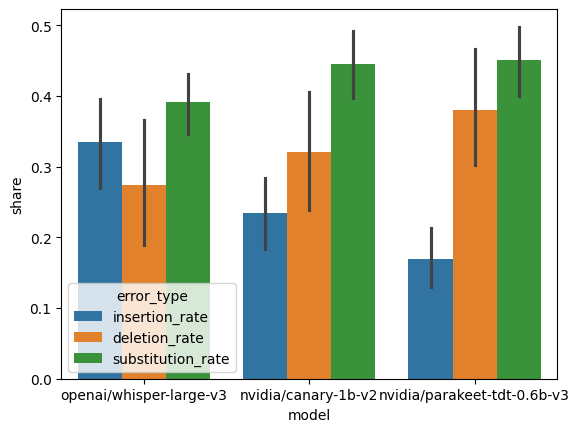

In [47]:

idf = pd.read_csv("results/evaluation_summary.csv")

model_labels = {
    'openai/whisper-large-v3':     'Whisper',
    'nvidia/canary-1b-v2':         'Canary',
    'nvidia/parakeet-tdt-0.6b-v3': 'Parakeet'
}



total_errors = idf['substitutions'] + idf['insertions'] + idf['deletions']
idf['total_errors'] = total_errors

# individual rates
idf['insertion_rate'] = idf['insertions']/total_errors
idf['deletion_rate'] = idf['deletions']/total_errors
idf['substitution_rate'] = idf['substitutions']/total_errors

df_melted = idf.melt(id_vars=['model'], value_vars=['insertion_rate','deletion_rate','substitution_rate'],
                    var_name='error_type', value_name='share')

sns.barplot(data = df_melted, x = "model", y = "share", hue='error_type')


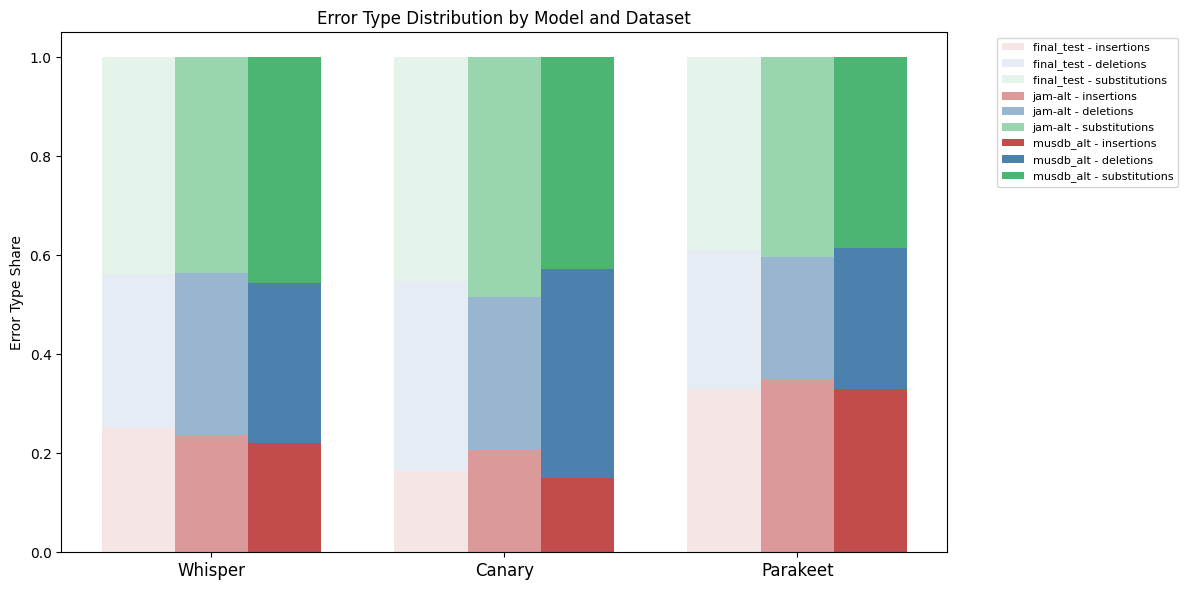

In [43]:
rdf = idf.groupby(['model', 'dataset'])[['insertion_rate', 'deletion_rate', 'substitution_rate','mean_wer']].mean()

fig, ax = plt.subplots(figsize=(12, 6))

models = rdf.index.get_level_values('model').unique()
x = np.arange(len(models))
width = 0.25
datasets = rdf.index.get_level_values('dataset').unique()

for i, dataset in enumerate(datasets):
    subset = rdf.xs(dataset, level='dataset')
    subset = subset.reindex(models)
    
    ax.bar(x + i * width, subset['insertion_rate'],  width, label=f'{dataset} - insertions',  color="#a90000", alpha=0.1 + i*0.3)
    ax.bar(x + i * width, subset['deletion_rate'],  width, label=f'{dataset} - deletions',   color="#004a8b", alpha=0.1 + i*0.3, bottom=subset['insertion_rate'])
    ax.bar(x + i * width, subset['substitution_rate'],  width, label=f'{dataset} - substitutions', color="#009639", alpha=0.1 + i*0.3, bottom=subset['insertion_rate'] + subset['deletion_rate'])

ax.set_xticks(x + width)
ax.set_xticklabels(['Whisper', 'Canary', 'Parakeet'], fontsize=12)
ax.set_ylabel('Error Type Share')
ax.set_title('Error Type Distribution by Model and Dataset')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()



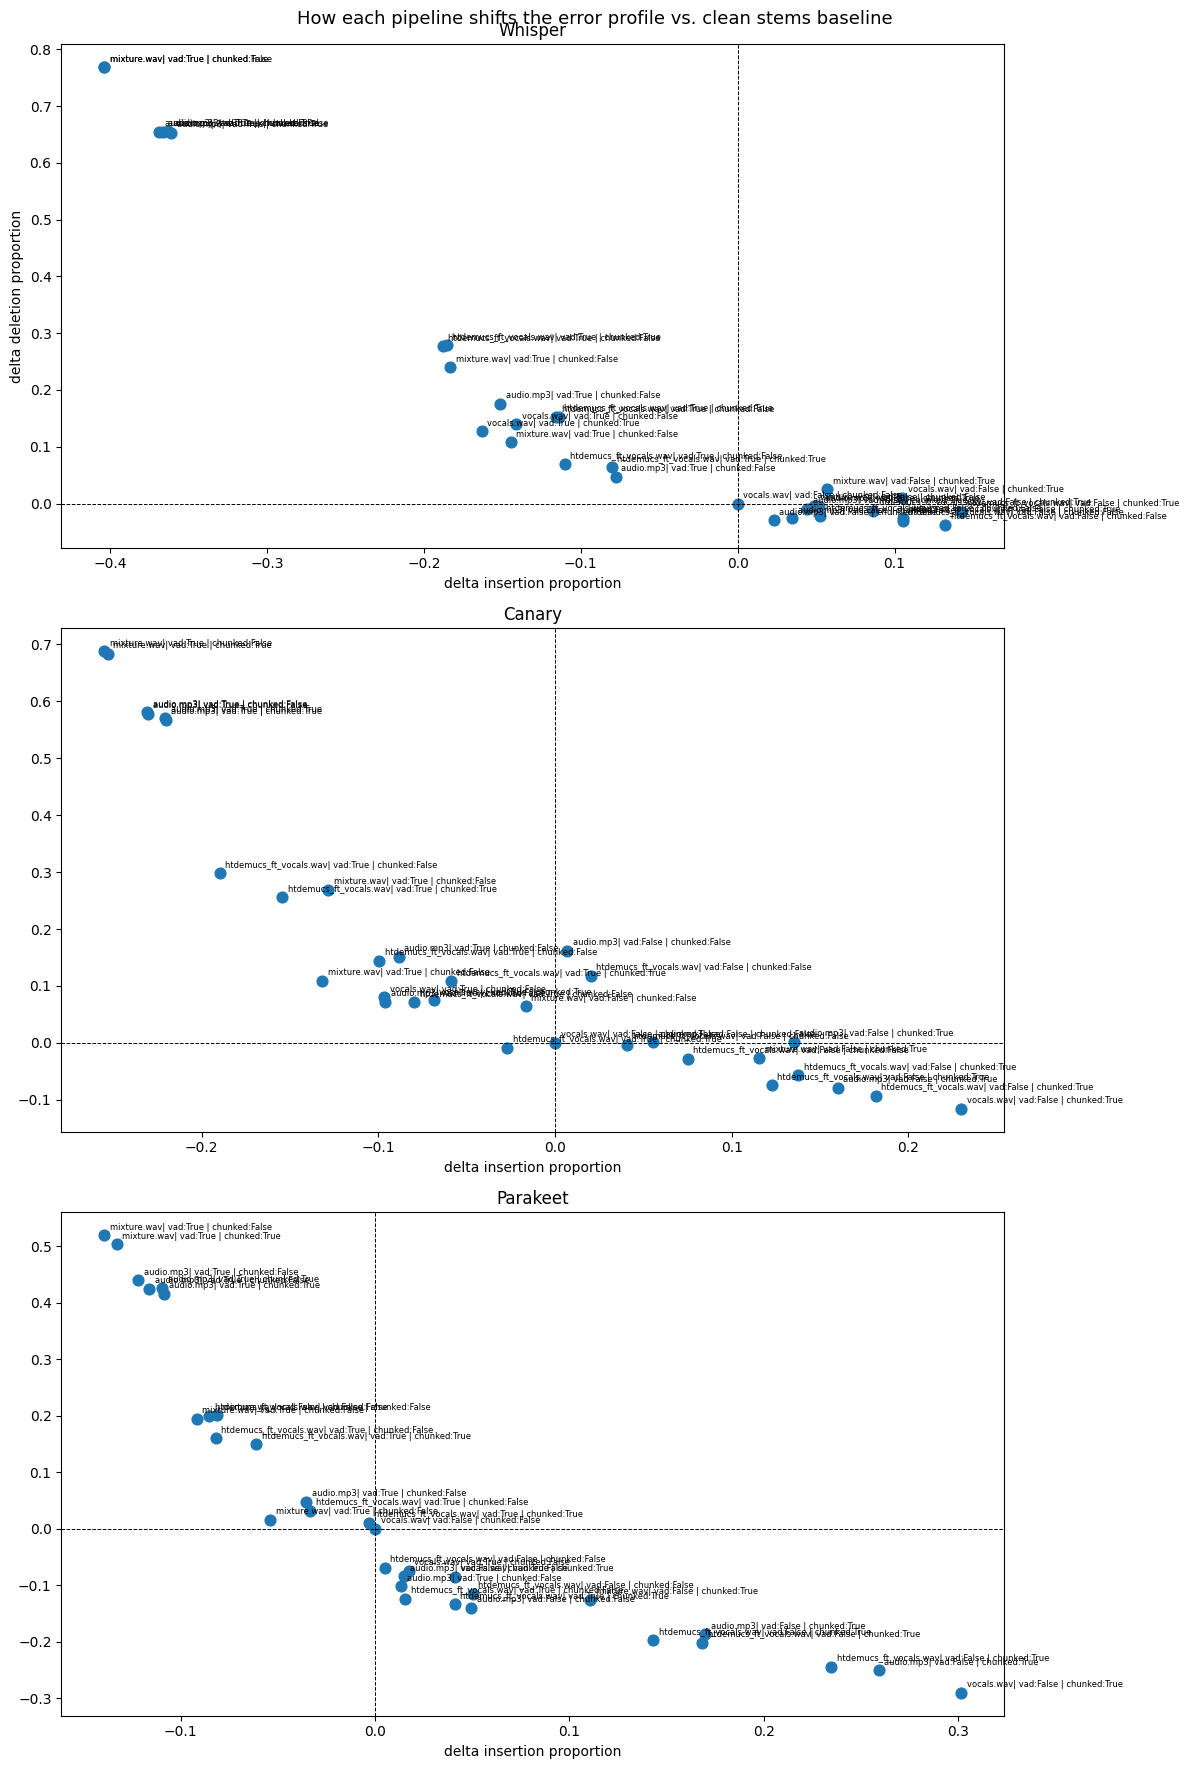

In [55]:

idf['insertion_prop'] = idf['insertions'] / idf['total_errors']
idf['deletion_prop'] = idf['deletions'] / idf['total_errors']
idf['substitution_prop'] = idf['substitutions'] /idf['total_errors']




fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharey=False, sharex=False)

for ax, (model_id, model_name) in zip(axes, model_labels.items()):

    m = idf[idf["model"] == model_id].copy()

    baseline = m[
        (m['filename'] == "vocals.wav") & (m['vad'] == False) & (m['chunked'] == False)
    ].iloc[0]


    m["d_insertion"] = m["insertion_prop"] -  baseline['insertion_prop']
    m['d_deletion'] = m["deletion_prop"] - baseline["deletion_prop"]

    m['pipeline'] = m['filename']  + '| vad:' + m['vad'].astype(str) + ' | chunked:' + m['chunked'].astype(str)

    ax.scatter(m['d_insertion'], m['d_deletion'], s=60)

    for _, row in m.iterrows():
        ax.annotate(row['pipeline'], (row['d_insertion'], row['d_deletion']),
                    fontsize=6, textcoords='offset points', xytext=(4, 4))
        
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel('delta insertion proportion')
    ax.set_ylabel('delta deletion proportion' if ax == axes[0] else '')



fig.suptitle('How each pipeline shifts the error profile vs. clean stems baseline', fontsize=13)
plt.tight_layout()
plt.show()